# Sparsity study 

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
import torch
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader
import importlib
import sys
sys.path.append('/Users/cyrilgarcia/notebooks/tsnn/')

import tsnn

from tsnn.generators import generators
from tsnn import tstorch
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn import utils
from tsnn.tstorch import transformers
import torch.nn.functional as F
import math
from typing import Optional

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from torch import nn
from tqdm import tqdm
device = 'mps'


plt.style.use('ggplot')

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    T: int = 4000
    n_ts: int = 10
    n_f: int = 20
    pct_zero_corr: float = 0.5
    split_conditional: float = 0.0
    split_shift: float = 1.0
    split_seasonal: float = 0.0
    split_cs: float = 0.0
    split_cs_shift: float = 0.0
    low_corr: float = 0.05
    high_corr: float = 0.1

In [3]:
z = generators.Generator(Config.T, Config.n_ts, Config.n_f)

In [4]:
%%time
z.generate_dataset(pct_zero_corr = Config.pct_zero_corr,
                  split_conditional = Config.split_conditional,
                  split_shift = Config.split_shift,
                  split_seasonal = Config.split_seasonal,
                  split_cs=Config.split_cs,
                  split_cs_shift=Config.split_cs_shift,
                  low_corr=Config.low_corr, 
                  high_corr=Config.high_corr)

CPU times: user 13.5 ms, sys: 3.79 ms, total: 17.3 ms
Wall time: 23.8 ms


In [5]:
z.get_dataloader(n_rolling=10)

In [6]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool


In [7]:
mask_fn = causal_mask
plot_mask(mask_fn, seq_len=5)

,0,1,2,3,4
0,1,0,0,0,0
1,1,1,0,0,0
2,1,1,1,0,0
3,1,1,1,1,0
4,1,1,1,1,1


In [8]:
mask_fn = causal_mask_radius
plot_mask(mask_fn, seq_len=5)

,0,1,2,3,4
0,1,0,0,0,0
1,1,1,0,0,0
2,0,1,1,0,0
3,0,0,1,1,0
4,0,0,0,1,1


In [9]:
from tsnn.tstorch import models

In [10]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmarkRolling(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

In [11]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

mask = causal_mask
mask = build_attention_mask(mask, 10, device=device)

In [12]:
def keep_topk_per_row(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

In [13]:
def keep_by_max_value(x, frac=0.1):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out

## List of sparse models

Tried and shown below, I only use a TC model (time + cross sectionnal) and 1 head to make everything simple. I look at a noisy setup of the temporal shift effect.
- Full attention matrix
- Top k coefficients per row of the attention matrix
- Including gated coefficients on each matrix diagonal to get the best MSE while maximizing the sparsity of the attention matrix
- After studying the attention matrix found by the full model, decided to use a method based on the max value of each row to clean the matrix (intuitive since this is a probability space)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:23<00:00,  1.20s/it]


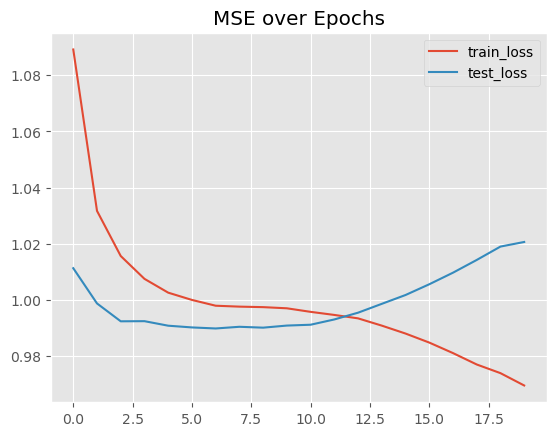

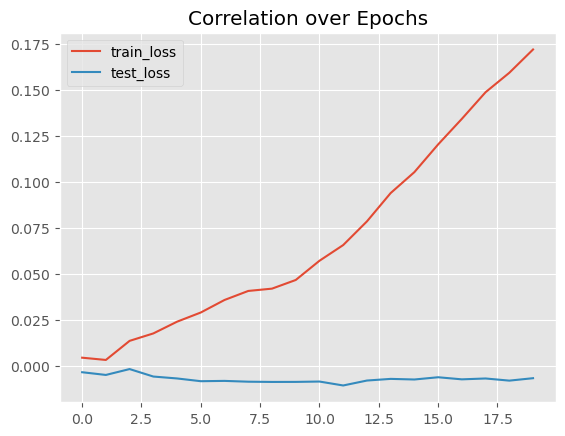

,true,optimal,shift
optimal,0.032,nan,nan
shift,0.032,1.000,nan
full_attention,0.203,0.053,0.053


,true,optimal,shift
optimal,0.033,nan,nan
shift,0.033,1.000,nan
full_attention,-0.005,0.033,0.033


In [17]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr, 
        random_ts_shift=4
    )
    
    models_linear = {}
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
#         'max_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
#         ).to(device),
        
#         'dynamic_sparse': sparse_model,
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    # # gated coefs print
    # print("Gated coefficients for sparse model:")
    # gated_coeffs = models_torch['dynamic_sparse'].model.get_gated_coeffs()
    # for i, coeffs in enumerate(gated_coeffs):
    #     print(f"Layer {i}: {coeffs.detach().cpu().numpy()}")
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

Full attention matrix

In [68]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.778,0.222,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.173,0.605,0.223,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.147,0.077,0.581,0.195,0.000,0.000,0.000,0.000,0.000,0.000
4,0.090,0.089,0.056,0.627,0.138,0.000,0.000,0.000,0.000,0.000
5,0.092,0.053,0.074,0.059,0.550,0.171,0.000,0.000,0.000,0.000
6,0.033,0.054,0.031,0.082,0.062,0.611,0.127,0.000,0.000,0.000
7,0.024,0.056,0.039,0.087,0.025,0.074,0.549,0.146,0.000,0.000
8,0.023,0.018,0.046,0.056,0.054,0.098,0.043,0.527,0.135,0.000
9,0.026,0.018,0.037,0.031,0.039,0.083,0.054,0.048,0.544,0.119


In [18]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.562,0.438,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.277,0.450,0.273,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.176,0.208,0.404,0.212,0.000,0.000,0.000,0.000,0.000,0.000
4,0.071,0.161,0.191,0.375,0.202,0.000,0.000,0.000,0.000,0.000
5,0.069,0.063,0.170,0.190,0.346,0.163,0.000,0.000,0.000,0.000
6,0.057,0.069,0.045,0.168,0.161,0.346,0.154,0.000,0.000,0.000
7,0.029,0.055,0.059,0.042,0.135,0.185,0.340,0.154,0.000,0.000
8,0.036,0.037,0.041,0.061,0.040,0.137,0.141,0.318,0.189,0.000
9,0.019,0.022,0.040,0.031,0.056,0.041,0.134,0.164,0.325,0.169


Sparsity matrix with the max proba algorithm

In [16]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.586,0.414,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.640,0.360,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.742,0.258,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.603,0.397,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.573,0.427,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.573,0.427,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.685,0.315,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.648,0.352,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.600,0.400


Preliminary conclusions:
- dynamic sparse seems to find the right coefficients but doesn't show a high improvement over the full attention. also there are some choices here of loss functions etc which may not be optimal
- the 2 sparse methods seem better than full and (expected) right below the informed model where we enforce the correct sparsity
- max_sparse is more stable (to confirm in bootstrap)

## TCTC models with temporal shift effect

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:26<00:00,  2.61s/it]


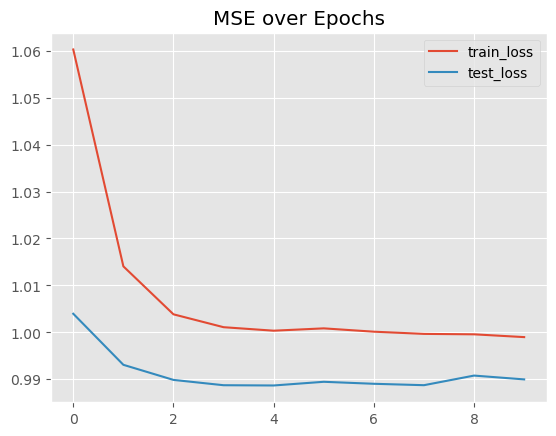

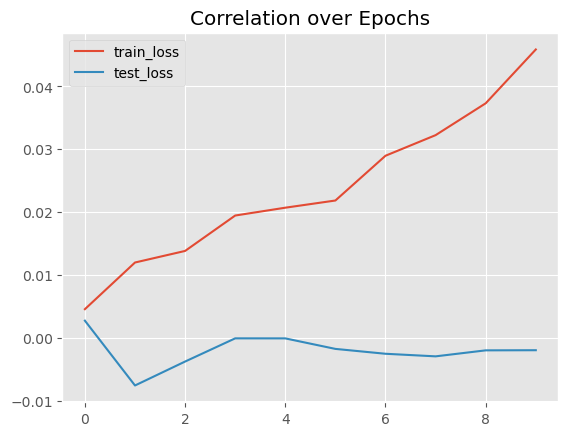

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:23<00:00,  2.40s/it]


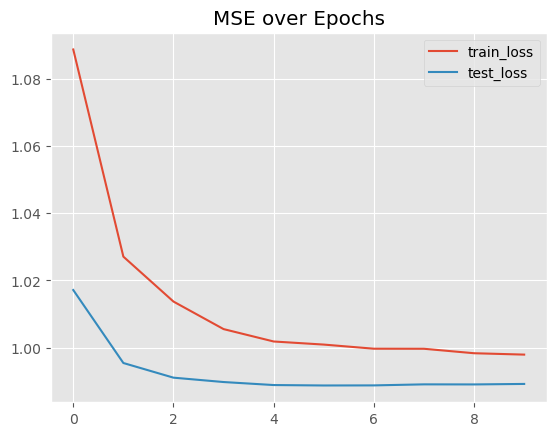

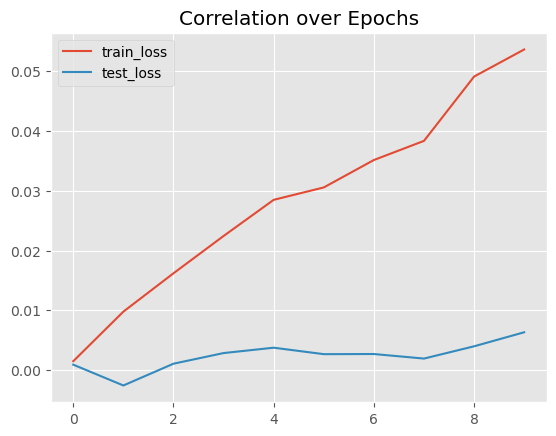

,true,optimal,shift,full_attention
optimal,0.092,nan,nan,nan
shift,0.092,1.000,nan,nan
full_attention,0.077,0.049,0.049,nan
max_sparse,0.096,0.026,0.026,0.641


,true,optimal,shift,full_attention
optimal,0.089,nan,nan,nan
shift,0.089,1.000,nan,nan
full_attention,-0.000,0.039,0.039,nan
max_sparse,0.006,0.003,0.003,0.641


In [31]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.03]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr,
        random_ts_shift=4,
        shuffle_cs=True
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TCTC', nhead=4,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=4,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=10)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

Full attention matrix FIRST layer

In [32]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.563,0.437,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.457,0.258,0.285,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.271,0.224,0.337,0.168,0.000,0.000,0.000,0.000,0.000,0.000
4,0.190,0.306,0.158,0.155,0.191,0.000,0.000,0.000,0.000,0.000
5,0.176,0.151,0.224,0.167,0.149,0.133,0.000,0.000,0.000,0.000
6,0.137,0.135,0.143,0.156,0.132,0.138,0.160,0.000,0.000,0.000
7,0.102,0.112,0.090,0.104,0.129,0.137,0.201,0.124,0.000,0.000
8,0.097,0.107,0.107,0.092,0.096,0.125,0.176,0.096,0.104,0.000
9,0.077,0.105,0.074,0.063,0.098,0.100,0.223,0.077,0.082,0.101


Full attention matrix SECOND layer

In [33]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[2].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.433,0.567,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.276,0.267,0.456,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.259,0.203,0.279,0.260,0.000,0.000,0.000,0.000,0.000,0.000
4,0.129,0.212,0.264,0.173,0.222,0.000,0.000,0.000,0.000,0.000
5,0.153,0.130,0.243,0.150,0.181,0.143,0.000,0.000,0.000,0.000
6,0.145,0.153,0.156,0.147,0.151,0.114,0.135,0.000,0.000,0.000
7,0.108,0.127,0.138,0.109,0.133,0.114,0.120,0.153,0.000,0.000
8,0.083,0.102,0.121,0.094,0.107,0.110,0.136,0.121,0.126,0.000
9,0.078,0.091,0.127,0.083,0.115,0.077,0.102,0.118,0.102,0.106


Sparsity matrix with the max proba algorithm FIRST layer

In [34]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.519,0.481,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.588,0.412,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.539,0.461,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.434,0.566,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.592,0.408,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.480,0.520,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.661,0.339,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.557,0.443,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.557,0.443


Sparsity matrix with the max proba algorithm SECOND layer

In [35]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[2].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.412,0.588,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.531,0.469,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.490,0.510,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.479,0.521,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.545,0.455,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.534,0.466,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.378,0.622,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.606,0.394,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.443,0.557


## Cross-sectionnal effect

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:23<00:00,  1.16s/it]


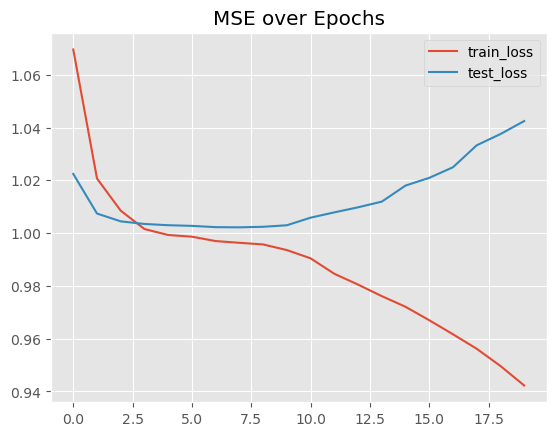

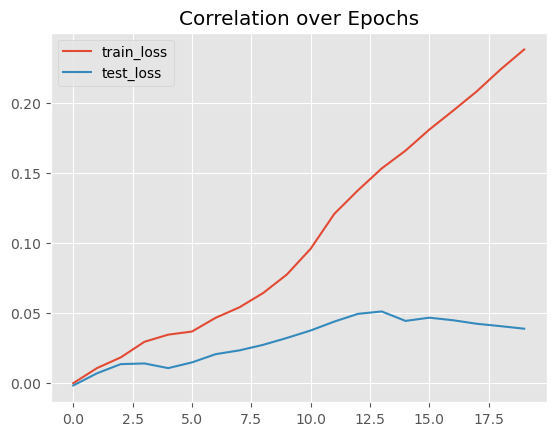

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:23<00:00,  1.16s/it]


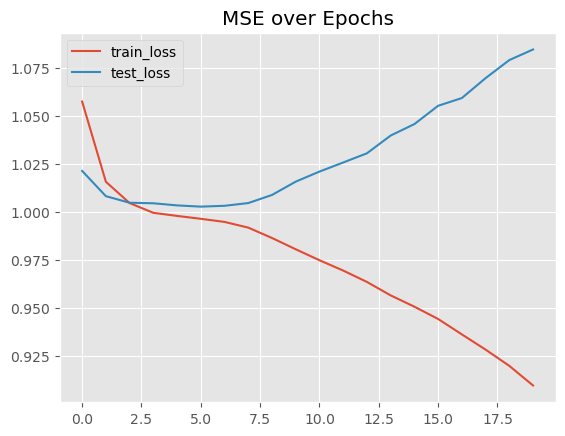

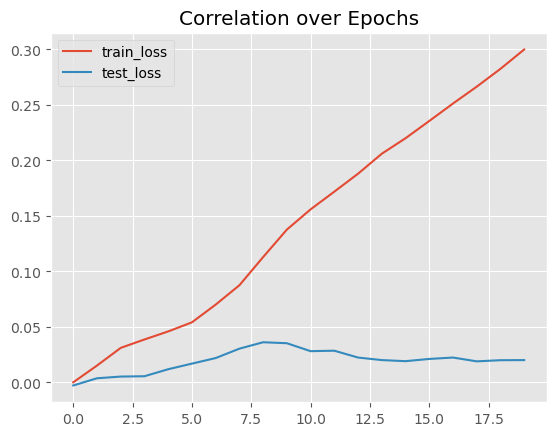

,true,optimal,cs,full_attention
optimal,0.154,nan,nan,nan
cs,0.154,1.000,nan,nan
full_attention,0.278,0.188,0.188,nan
max_sparse,0.343,0.154,0.154,0.326


,true,optimal,cs,full_attention
optimal,0.154,nan,nan,nan
cs,0.154,1.000,nan,nan
full_attention,0.043,0.177,0.177,nan
max_sparse,0.017,0.112,0.112,0.275


In [44]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 1.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr,
        shuffle_cs=True
    )
    
    models_linear = {}
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)

    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

In [45]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,0.007,0.229,0.051,0.028,0.051,0.111,0.227,0.161,0.030,0.104
1,0.062,0.016,0.069,0.227,0.037,0.017,0.056,0.134,0.209,0.174
2,0.021,0.019,0.030,0.169,0.093,0.129,0.078,0.142,0.114,0.204
3,0.025,0.070,0.040,0.084,0.008,0.032,0.110,0.115,0.235,0.282
4,0.132,0.020,0.008,0.044,0.018,0.232,0.336,0.125,0.005,0.078
5,0.199,0.280,0.066,0.117,0.052,0.037,0.158,0.033,0.006,0.052
6,0.070,0.142,0.024,0.128,0.014,0.158,0.055,0.184,0.118,0.107
7,0.201,0.008,0.237,0.136,0.018,0.077,0.054,0.032,0.007,0.230
8,0.042,0.241,0.032,0.052,0.010,0.207,0.101,0.098,0.054,0.164
9,0.004,0.193,0.004,0.040,0.004,0.039,0.613,0.028,0.005,0.068


In [46]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,0.000,0.152,0.247,0.000,0.000,0.162,0.153,0.040,0.000,0.247
1,0.278,0.000,0.000,0.000,0.000,0.000,0.352,0.311,0.000,0.059
2,0.000,0.087,0.236,0.069,0.054,0.000,0.058,0.301,0.039,0.156
3,0.000,0.076,0.077,0.233,0.042,0.165,0.143,0.000,0.187,0.077
4,0.157,0.045,0.034,0.045,0.000,0.189,0.344,0.000,0.047,0.139
5,0.554,0.088,0.000,0.120,0.000,0.146,0.000,0.000,0.000,0.093
6,0.045,0.000,0.089,0.043,0.065,0.213,0.167,0.201,0.130,0.048
7,0.219,0.000,0.138,0.000,0.000,0.479,0.091,0.073,0.000,0.000
8,0.171,0.239,0.000,0.062,0.000,0.049,0.000,0.379,0.000,0.100
9,0.000,0.212,0.033,0.042,0.000,0.287,0.323,0.068,0.034,0.000


## CS + tempporal shift

In [19]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.03]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 1.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

 20%|██████████████████████                                                                                        | 4/20 [00:06<00:24,  1.52s/it]


KeyboardInterrupt: 

## Bootstrapping

In [14]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


def run_bootstrap(c, effect, n=40, T=4000, n_ts=10, n_f=20, models_torch=None, epochs=15):
    arg_list = {'d_lin': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cond': {'pct_zero_corr': 0.5, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
                'd_shift': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cs': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
                'd_cs_shift': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
                'd_all': {'pct_zero_corr': 0.5, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
               }
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []
    for i in tqdm(range(n)):
        z.generate_dataset( 
                pct_zero_corr=arg_list[effect]['pct_zero_corr'],
                split_conditional=arg_list[effect]['split_conditional'],
                split_shift=arg_list[effect]['split_shift'],
                split_seasonal=arg_list[effect]['split_seasonal'],
                split_cs=arg_list[effect]['split_cs'],
                split_cs_shift=arg_list[effect]['split_cs_shift'],
                low_corr=c,
                high_corr=c,
            )

        z.get_dataloader()
        
        models_linear = {'lasso': ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                          verbose=False, max_iter=1000, selection='random', n_jobs=5, cv=3)),
                         'boosting': ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, 
                                                                                                        n_iter_no_change=100))}
        # models_linear = {}


        if effect == 'd_shift':
            models_torch = {
                'full_attention': models.CustomBiDimensionalTransformer(
                    n_ts, n_f, 10, mask=mask_c, layers='TC', nhead=1,
                    dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
                ).to(device),
                'deterministic_sparse': models.CustomBiDimensionalTransformer(
                    n_ts, n_f, 10, mask=mask_1, layers='TC', nhead=1,
                    dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
                ).to(device),

                # 'top_k_sparse': models.CustomBiDimensionalTransformer(
                #     n_ts, n_f, 10, mask=mask_c, layers='TC', nhead=1,
                #     dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
                # ).to(device),

                'max_sparse': models.CustomBiDimensionalTransformer(
                    n_ts, n_f, 10, mask=mask_c, layers='TC', nhead=1,
                    dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
                ).to(device),
            }
        else:
            models_torch = {
                'full_attention': models.CustomBiDimensionalTransformer(
                    n_ts, n_f, 10, mask=mask_c, layers='TC', nhead=1,
                    dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
                ).to(device),
                
                # 'top_k_sparse': models.CustomBiDimensionalTransformer(
                #     n_ts, n_f, 10, mask=mask_c, layers='TC', nhead=1,
                #     dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
                # ).to(device),

                'max_sparse': models.CustomBiDimensionalTransformer(
                    n_ts, n_f, 10, mask=mask_c, layers='TC', nhead=1,
                    dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
                ).to(device),
            }


        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
                device=device
            ) for k in models_torch
        }


        z.get_dataloader(n_rolling=10, roll_y=True)
        for k in models_torch:
            models_torch[k].fit(z.train, test=z.test, epochs=epochs, plot=False, verbose=0)
            
        for k in models_linear:
            models_linear[k].fit(z.train)

        comp = benchmark_comparison.Comparator(models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
        )
        
        # display(comp.correl(z, mode="test"))
        
        res_train.append(comp.correl(z, mode="train", return_values=True)['optimal'])
        res_test.append(comp.correl(z, mode="test", return_values=True)['optimal'])
        
    return res_train, res_test

############## WARNING TAKES TIME TO RUN ######

In [19]:
cs = [0.005, 
      0.01,
      0.03
     ]
effects = [
    'd_shift', 
           'd_cs', 
    # 'd_cs_shift', 
    #        'd_all',
    #        'd_cond', 'd_lin'
          ]

import warnings

for c in cs:
    for effect in effects:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r_train, r_test = run_bootstrap(c, effect, n=30, n_ts=10, n_f=20)
        pd.concat(r_train, axis=1).T.to_parquet(f'sparse_results/sparse_{effect}_{c}_train.parquet')
        pd.concat(r_test, axis=1).T.to_parquet(f'sparse_results/sparse_{effect}_{c}_test.parquet')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [27:30<00:00, 55.03s/it]


In [ ]:
cs = [0.005, 
      0.01,
      0.03
     ]
effects = [
    'd_shift', 
           'd_cs', 
    # 'd_cs_shift', 
           'd_all',
    #        'd_cond', 
    'd_lin'
          ]

import warnings

for c in cs:
    for effect in effects:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r_train, r_test = run_bootstrap(c, effect, n=60, n_ts=10, n_f=20)
        pd.concat(r_train, axis=1).T.to_parquet(f'sparse_results3/sparse_{effect}_{c}_train.parquet')
        pd.concat(r_test, axis=1).T.to_parquet(f'sparse_results3/sparse_{effect}_{c}_test.parquet')

 52%|█████████████████████████████████████████████████████████▎                                                     | 31/60 [27:50<28:15, 58.47s/it]

In [20]:
cs = [0.005, 0.01, 0.03]
effects = ['d_shift', 'd_cs', 
           # 'd_cs_shift', 
           # 'd_all',
           # 'd_cond', 'd_lin'
          ]

import warnings

for c in cs:
    for effect in effects:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r_train, r_test = run_bootstrap(c, effect, n=30, n_ts=20, n_f=10)
        pd.concat(r_train, axis=1).T.to_parquet(f'sparse_results2/sparse_{effect}_{c}_train.parquet')
        pd.concat(r_test, axis=1).T.to_parquet(f'sparse_results2/sparse_{effect}_{c}_test.parquet')

 13%|██████████████▌                                                                                              | 4/30 [12:56<1:24:09, 194.22s/it]python(89755,0x1f3c360c0) malloc: small_free_list_remove_ptr_no_clear: Internal invariant broken (next ptr of prev) for 0x38aaac400, prev_next=0x374ff0a00

python(89755,0x1f3c360c0) malloc: *** set a breakpoint in malloc_error_break to debug


RuntimeError: DataLoader worker (pid 89755) is killed by signal: Abort trap: 6. 

## DRAFT

In [42]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmarkRolling(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:13<00:00,  1.08it/s]


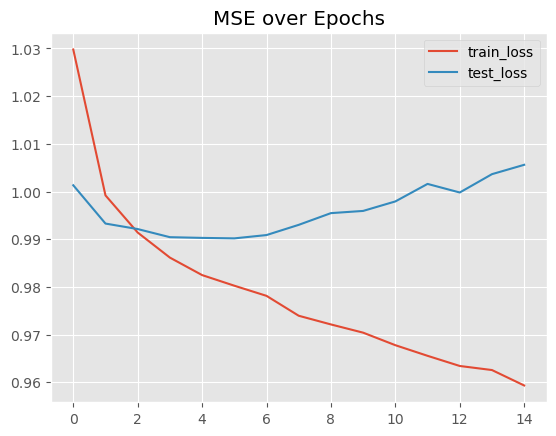

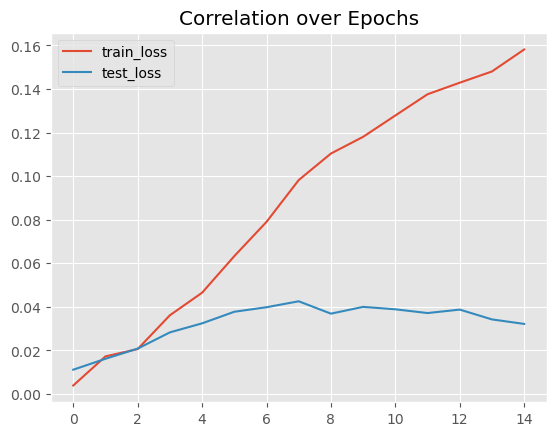

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:09<00:00,  1.56it/s]


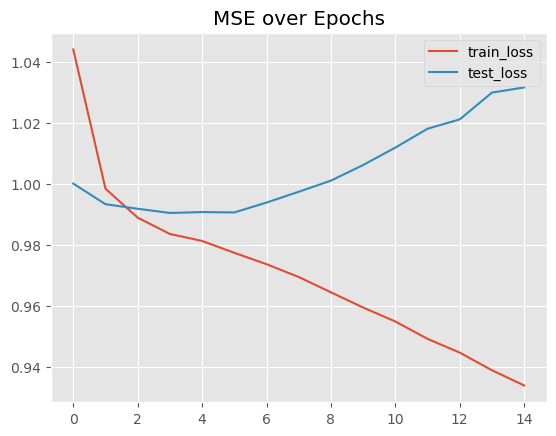

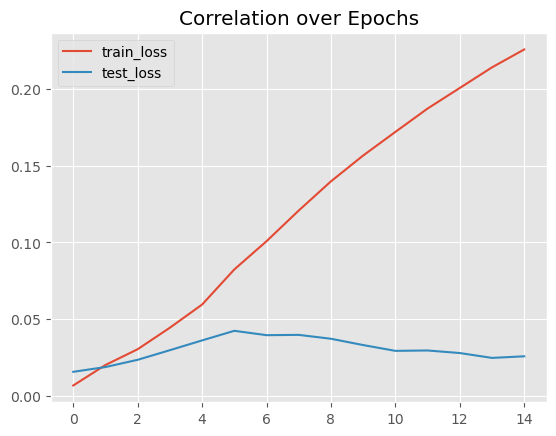

,true,optimal,cs,lasso,boosting,mlp,full_attention
optimal,0.117,nan,nan,nan,nan,nan,nan
cs,0.117,1.000,nan,nan,nan,nan,nan
lasso,0.117,0.268,0.268,nan,nan,nan,nan
boosting,0.672,0.105,0.105,0.192,nan,nan,nan
mlp,0.983,0.117,0.117,0.121,0.662,nan,nan
full_attention,0.180,0.264,0.264,0.235,0.141,0.180,nan
CC,0.246,0.259,0.259,0.175,0.190,0.243,0.358


,true,optimal,cs,lasso,boosting,mlp,full_attention
optimal,0.102,nan,nan,nan,nan,nan,nan
cs,0.102,1.000,nan,nan,nan,nan,nan
lasso,0.028,0.268,0.268,nan,nan,nan,nan
boosting,0.004,0.052,0.052,0.197,nan,nan,nan
mlp,0.001,0.038,0.038,0.169,0.056,nan,nan
full_attention,0.039,0.231,0.231,0.214,0.024,0.044,nan
CC,0.025,0.228,0.228,0.139,0.026,0.030,0.319


In [59]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.05]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 10
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 1.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr,
        shuffle_cs=True
    )
    
    z.get_dataloader(n_rolling=10)
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'CC': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='CC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        # 'max_sparse': models.CustomBiDimensionalTransformer(
        #     Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
        #     dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        # ).to(device),
        
    }
    
    models_no_roll = {'MLP': models.GlobalMLP(Config.n_ts, Config.n_f, 10, dropout=0.3).to(device)}


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }
    
    models_no_roll = {
        k: torch_benchmarks.TorchWrapper(
            models_no_roll[k], 
            optimizer=torch.optim.AdamW(models_no_roll[k].parameters(), lr=0.001),
            loss_fn=nn.MSELoss(),
            device=device
        ) for k in models_no_roll
    }
    models_no_roll = {}

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=15)
    
    # z.get_dataloader(n_rolling=10, roll_y=False)
    # for k in models_no_roll:
    #     models_no_roll[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch] + [models_no_roll[k] for k in models_no_roll], 
        model_names=[k for k in models_linear] + [k for k in models_torch] + [k for k in models_no_roll]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

In [20]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmark(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmark(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmark(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

In [61]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 2, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 2, device=device)


for c in [0.03]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 1.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 2, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 2, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }
    
    models_no_roll = {'MLP': models.GlobalMLP(Config.n_ts, Config.n_f, 2, dropout=0.3).to(device)}


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }
    
    models_no_roll = {
        k: torch_benchmarks.TorchWrapper(
            models_no_roll[k], 
            optimizer=torch.optim.AdamW(models_no_roll[k].parameters(), lr=0.001),
            loss_fn=nn.MSELoss(),
            device=device
        ) for k in models_no_roll
    }

    
    z.get_dataloader(n_rolling=2, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    z.get_dataloader(n_rolling=2, roll_y=False)
    for k in models_no_roll:
        models_no_roll[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch] + [models_no_roll[k] for k in models_no_roll], 
        model_names=[k for k in models_linear] + [k for k in models_torch] + [k for k in models_no_roll]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

 50%|██████████████████████████████████████████████████████▌                                                      | 10/20 [00:04<00:04,  2.40it/s]


KeyboardInterrupt: 

In [48]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmarkRolling(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:13<00:00,  1.10it/s]


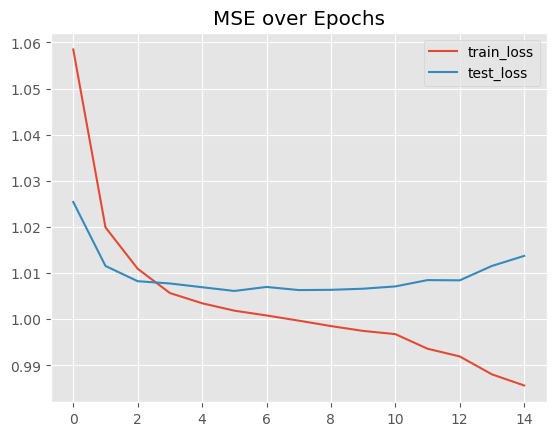

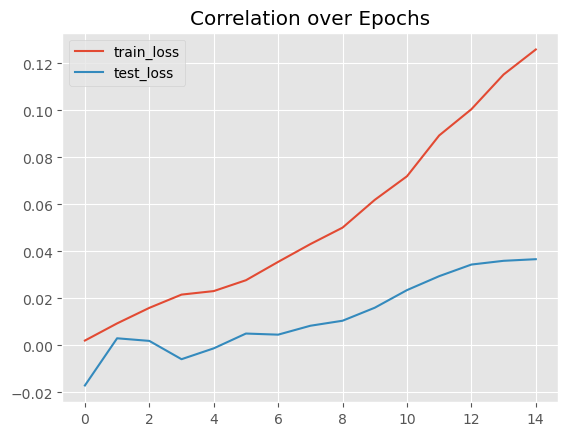

,true,optimal,shift,lasso,boosting,mlp
optimal,0.112,nan,nan,nan,nan,nan
shift,0.112,1.000,nan,nan,nan,nan
lasso,0.151,0.903,0.903,nan,nan,nan
boosting,0.679,0.292,0.292,0.338,nan,nan
mlp,0.985,0.113,0.113,0.152,0.670,nan
full_attention,0.156,0.267,0.267,0.258,0.174,0.153


,true,optimal,shift,lasso,boosting,mlp
optimal,0.102,nan,nan,nan,nan,nan
shift,0.102,1.000,nan,nan,nan,nan
lasso,0.089,0.904,0.904,nan,nan,nan
boosting,0.041,0.395,0.395,0.432,nan,nan
mlp,0.015,0.156,0.156,0.211,0.128,nan
full_attention,0.038,0.258,0.258,0.246,0.096,0.065


In [58]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.05]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 10
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr,
        shuffle_cs=True, random_ts_shift=5
    )
    
    z.get_dataloader(n_rolling=10)
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        # 'max_sparse': models.CustomBiDimensionalTransformer(
        #     Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
        #     dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        # ).to(device),
        
    }
    
    models_no_roll = {'MLP': models.GlobalMLP(Config.n_ts, Config.n_f, 10, dropout=0.3).to(device)}


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }
    
    models_no_roll = {
        k: torch_benchmarks.TorchWrapper(
            models_no_roll[k], 
            optimizer=torch.optim.AdamW(models_no_roll[k].parameters(), lr=0.001),
            loss_fn=nn.MSELoss(),
            device=device
        ) for k in models_no_roll
    }
    models_no_roll = {}

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=15)
    
    # z.get_dataloader(n_rolling=10, roll_y=False)
    # for k in models_no_roll:
    #     models_no_roll[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch] + [models_no_roll[k] for k in models_no_roll], 
        model_names=[k for k in models_linear] + [k for k in models_torch] + [k for k in models_no_roll]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))